In [47]:
import pandas as pd

In [48]:
df = pd.read_csv("/content/data.csv")

In [49]:
df

,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.9950,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563000,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.9940,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901000,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.6040,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.9950,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887000,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
4,0.9900,"['Frédéric Chopin', 'Vladimir Horowitz']",0.210,687733,0.2040,0,6N6tiFZ9vLTSOIxkj8qKrd,0.908000,11,0.0980,-16.829,1,"Polonaise-Fantaisie in A-Flat Major, Op. 61",1,1928,0.0424,62.149,0.0693,1928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169904,0.1730,"['DripReport', 'Tyga']",0.875,163800,0.4430,1,4KppkflX7I3vJQk7urOJaS,0.000032,1,0.0891,-7.461,1,Skechers (feat. Tyga) - Remix,75,2020-05-15,0.1430,100.012,0.3060,2020
169905,0.0167,"['Leon Bridges', 'Terrace Martin']",0.719,167468,0.3850,0,1ehhGlTvjtHo2e4xJFB0SZ,0.031300,8,0.1110,-10.907,1,Sweeter (feat. Terrace Martin),64,2020-06-08,0.0403,128.000,0.2700,2020
169906,0.5380,"['Kygo', 'Oh Wonder']",0.514,180700,0.5390,0,52eycxprLhK3lPcRLbQiVk,0.002330,7,0.1080,-9.332,1,How Would I Know,70,2020-05-29,0.1050,123.700,0.1530,2020
169907,0.0714,"['Cash Cash', 'Andy Grammer']",0.646,167308,0.7610,0,3wYOGJYD31sLRmBgCvWxa4,0.000000,1,0.2220,-2.557,1,I Found You,70,2020-02-28,0.0385,129.916,0.4720,2020


In [50]:
df = df.drop_duplicates(subset=["artists", "name"])

In [51]:
df.describe()

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,valence,year
count,156608.000000,156608.000000,1.566080e+05,156608.000000,156608.000000,156608.000000,156608.000000,156608.000000,156608.000000,156608.000000,156608.000000,156608.000000,156608.000000,156608.000000,156608.000000
mean,0.495783,0.537458,2.310463e+05,0.487088,0.086905,0.163163,5.200967,0.207698,-11.393035,0.707505,31.156588,0.096316,116.896800,0.531012,1977.204511
std,0.376842,0.175659,1.221553e+05,0.267400,0.281697,0.309991,3.515506,0.177673,5.665935,0.454910,21.513933,0.154385,30.790044,0.262406,25.671797
min,0.000000,0.000000,5.991000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1921.000000
25%,0.095700,0.416000,1.706400e+05,0.262000,0.000000,0.000000,2.000000,0.098700,-14.514000,0.000000,12.000000,0.035000,93.363750,0.321000,1956.000000
50%,0.499000,0.547000,2.080405e+05,0.478000,0.000000,0.000214,5.000000,0.136000,-10.499000,1.000000,33.000000,0.045300,114.765500,0.543000,1978.000000
75%,0.890000,0.667000,2.625330e+05,0.708000,0.000000,0.092125,8.000000,0.264000,-7.132750,1.000000,48.000000,0.076800,135.750250,0.748000,1999.000000
max,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,11.000000,1.000000,3.855000,1.000000,97.000000,0.969000,244.091000,1.000000,2020.000000


In [52]:
X = df.drop(["artists", "id", "name", "release_date"], axis=1)
X = X.iloc[:5000, :]

In [53]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X["duration_ms"] = np.log1p(X["duration_ms"])

to_scale = ["duration_ms", "tempo", "year", "loudness"]
scaler = StandardScaler()
# X_scaled = X.copy()
# X_scaled[to_scale] = scaler.fit_transform(X[to_scale])
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [54]:
X_scaled

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,valence,year
0,1.084903,1.218845,-0.571592,-0.878727,-0.14646,1.044487,1.403727,-0.349254,0.122677,0.624228,-1.295284,-0.254170,0.134691,0.917994,-2.238478
1,1.082085,-0.736087,0.659909,-1.588610,-0.14646,2.044813,0.831548,-0.748920,-2.848067,0.624228,-1.295284,-0.280992,-1.016466,-1.695786,-2.238478
2,-0.016654,1.462469,-1.468792,-0.780947,-0.14646,-0.621736,-0.026721,-0.520463,-1.266859,-1.601978,-1.295284,5.100525,-0.242121,1.293890,-2.238478
3,1.084903,1.652614,-0.292468,-1.132955,-0.14646,2.003379,-1.171079,-0.563265,-0.304787,-1.601978,-1.295284,0.001860,-0.214557,0.698411,-2.238478
4,1.070816,-1.740292,2.565962,-0.843527,-0.14646,2.065530,1.689817,-0.632819,-0.693138,0.624228,-1.225132,-0.304157,-1.744695,-1.723327,-2.238478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5013,0.127027,1.414933,0.332026,-0.581476,-0.14646,-0.621636,-0.026721,-0.630144,-0.722797,0.624228,1.510790,-0.386453,-0.334655,0.854725,1.625729
5014,-0.489957,-0.129999,1.878182,-1.058643,-0.14646,-0.621736,-1.457169,-0.381355,-0.749305,0.624228,1.300335,-0.275506,0.346022,-0.086876,1.625729
5015,-0.766051,-1.027247,0.503822,0.282899,-0.14646,2.109923,-1.171079,-0.520463,0.353277,0.624228,0.739120,-0.150539,-1.377494,-1.262948,1.625729
5016,0.710204,0.535510,-0.189123,-0.644055,-0.14646,-0.621440,-0.312810,-0.726984,-0.618248,0.624228,1.510790,-0.202354,1.313879,0.088045,1.625729


### Kmeans

In [89]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


inertia = []
silhouette = []
db_score = []
ch_score = []

clusters = range(2, 10)
for cluster in clusters:
  kmeans = KMeans(n_clusters=cluster, random_state=42)

  labels = kmeans.fit_predict(X_scaled)

  inertia.append(kmeans.inertia_)
  silhouette.append(silhouette_score(X_scaled, labels, sample_size=10000))
  db_score.append(davies_bouldin_score(X_scaled, labels))
  ch_score.append(calinski_harabasz_score(X_scaled, labels))

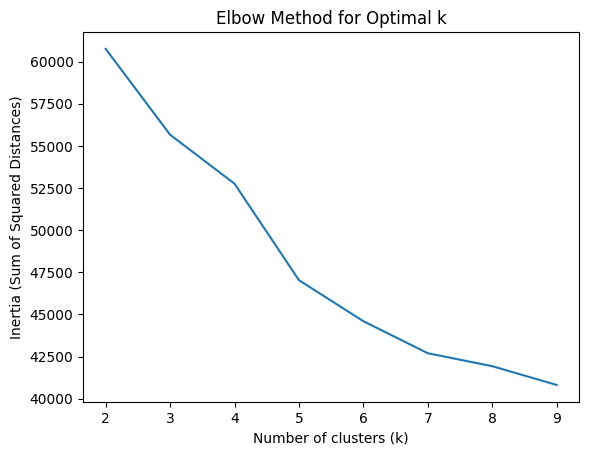

In [56]:
import matplotlib.pyplot as plt

plt.plot(clusters, inertia)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(clusters)

plt.show()

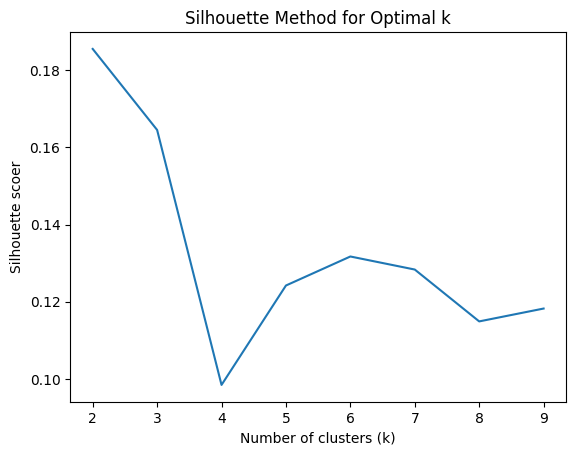

In [57]:
import matplotlib.pyplot as plt

plt.plot(clusters, silhouette)
plt.title('Silhouette Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette scoer')
plt.xticks(clusters)

plt.show()

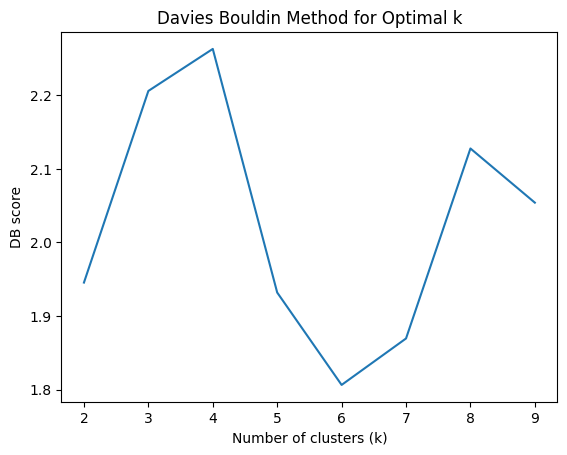

In [58]:
import matplotlib.pyplot as plt

plt.plot(clusters, db_score)
plt.title('Davies Bouldin Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('DB score')
plt.xticks(clusters)

plt.show()

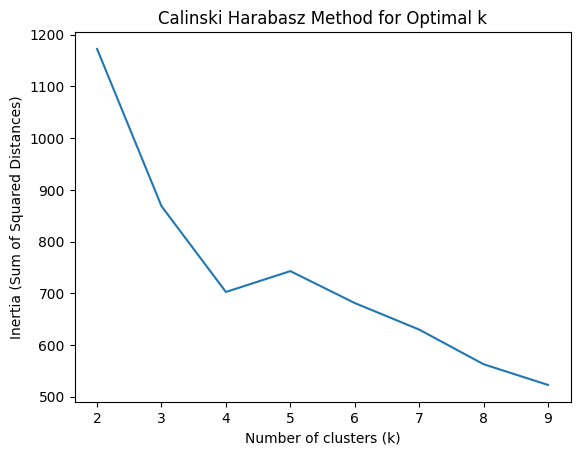

In [90]:
import matplotlib.pyplot as plt

plt.plot(clusters, ch_score)
plt.title('Calinski Harabasz Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(clusters)

plt.show()

In [59]:
kmeans = KMeans(n_clusters=3, random_state=42)

labels = kmeans.fit_predict(X_scaled)


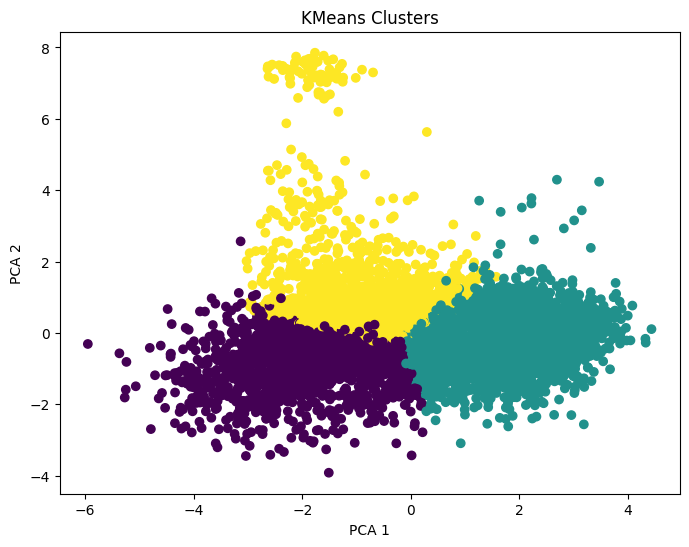

In [60]:
from sklearn.decomposition import PCA


def show_clusters(labels, name):
  pca = PCA(n_components=2)
  X_2d = pca.fit_transform(X_scaled)

  plt.figure(figsize=(8, 6))
  plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels)
  plt.xlabel("PCA 1")
  plt.ylabel("PCA 2")
  plt.title(f"{name} Clusters")
  plt.show()

show_clusters(labels, kmeans.__class__.__name__)

We see that there are 3 almost well separated clusters.

### PAM (Partitioning around Medoids)

In [61]:
!pip install "numpy<2" -q
!pip install -U scikit-learn-extra -q

In [91]:
from sklearn_extra.cluster import KMedoids

silhouette = []
db_score = []
ch_score = []

clusters = range(2, 10)
for cluster in clusters:
  model = KMedoids(n_clusters=cluster, random_state=42)

  labels = model.fit_predict(X_scaled)

  silhouette.append(silhouette_score(X_scaled, labels, sample_size=10000))
  db_score.append(davies_bouldin_score(X_scaled, labels))
  ch_score.append(calinski_harabasz_score(X_scaled, labels))

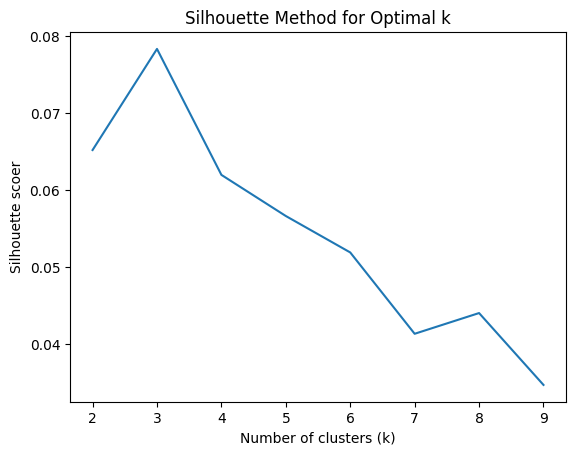

In [92]:
import matplotlib.pyplot as plt

plt.plot(clusters, silhouette)
plt.title('Silhouette Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette scoer')
plt.xticks(clusters)

plt.show()

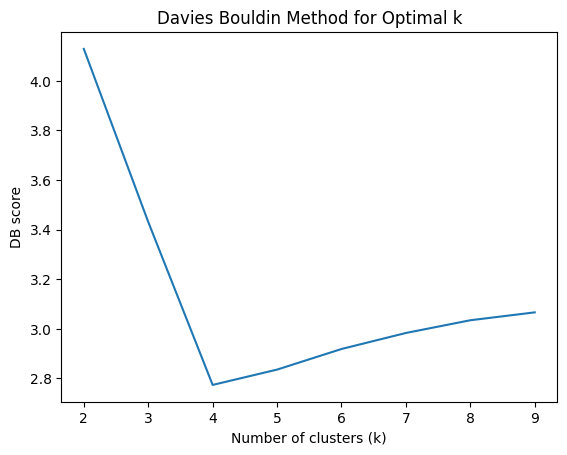

In [93]:
import matplotlib.pyplot as plt

plt.plot(clusters, db_score)
plt.title('Davies Bouldin Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('DB score')
plt.xticks(clusters)

plt.show()

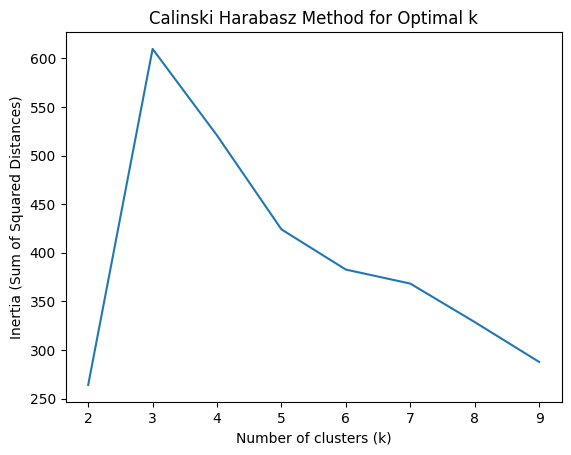

In [94]:
import matplotlib.pyplot as plt

plt.plot(clusters, ch_score)
plt.title('Calinski Harabasz Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(clusters)

plt.show()

In [87]:
medoids = KMedoids(n_clusters=3, random_state=42)
labels = medoids.fit_predict(X_scaled)

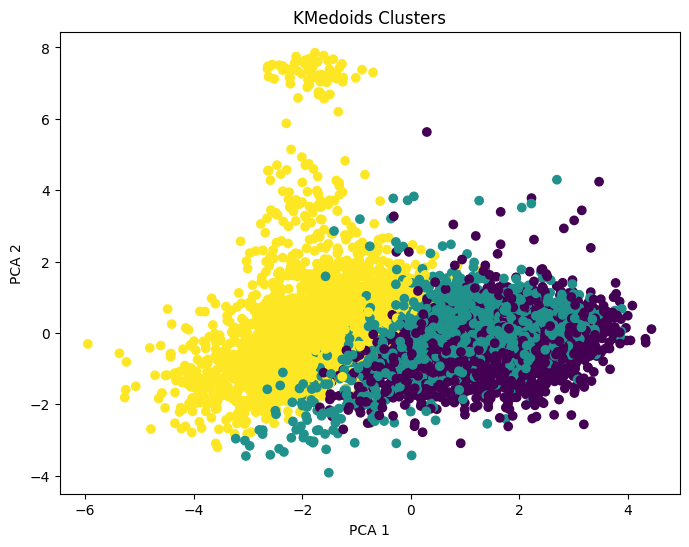

In [88]:
show_clusters(labels, medoids.__class__.__name__)

Yellow cluster is clearly separated, but other two overlap. That means that there are naturally might be only 2 clusters. But nevertheless it still has weak cluster structure.

###  CLARA (Clustering Large Applications)

In [66]:
!pip install pyclustering

In [95]:
from sklearn_extra.cluster import CLARA

silhouette = []
db_score = []
ch_score = []

clusters = range(2, 10)
for cluster in clusters:
  model = CLARA(n_clusters=cluster, random_state=42)

  labels = model.fit_predict(X_scaled)

  silhouette.append(silhouette_score(X_scaled, labels, sample_size=10000))
  db_score.append(davies_bouldin_score(X_scaled, labels))
  ch_score.append(calinski_harabasz_score(X_scaled, labels))


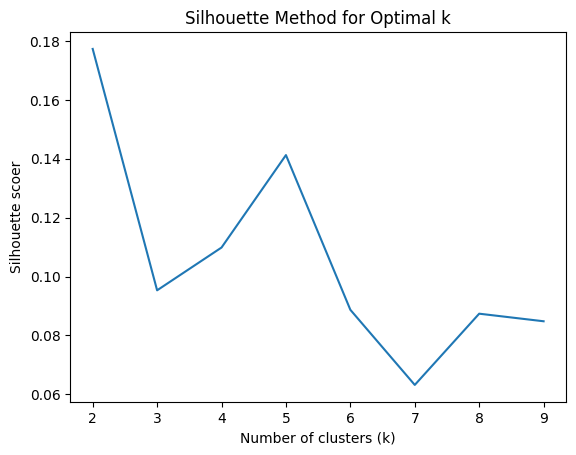

In [68]:
import matplotlib.pyplot as plt

plt.plot(clusters, silhouette)
plt.title('Silhouette Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette scoer')
plt.xticks(clusters)

plt.show()

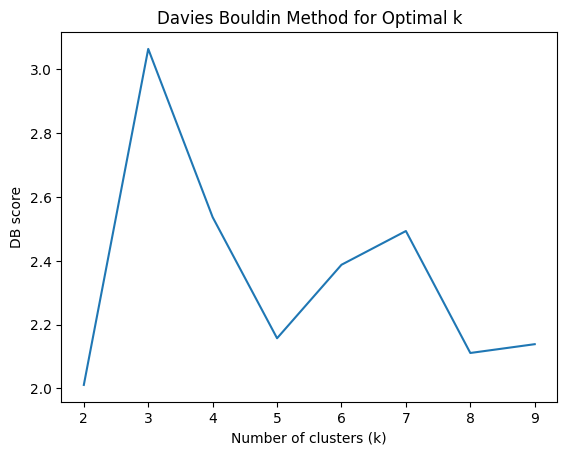

In [96]:
import matplotlib.pyplot as plt

plt.plot(clusters, db_score)
plt.title('Davies Bouldin Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('DB score')
plt.xticks(clusters)

plt.show()

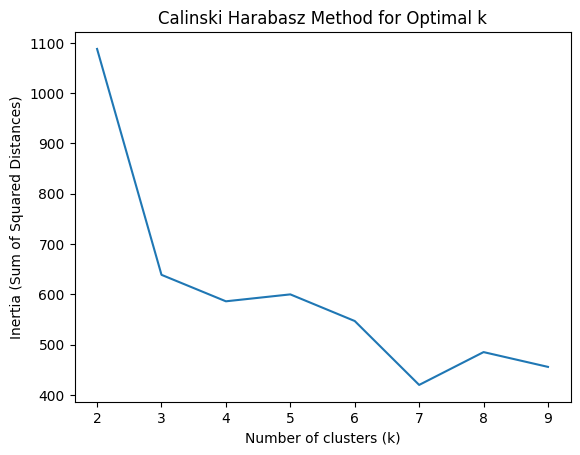

In [97]:
import matplotlib.pyplot as plt

plt.plot(clusters, ch_score)
plt.title('Calinski Harabasz Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(clusters)

plt.show()

In [69]:
clara = CLARA(n_clusters=2, random_state=42)
labels = clara.fit_predict(X_scaled)

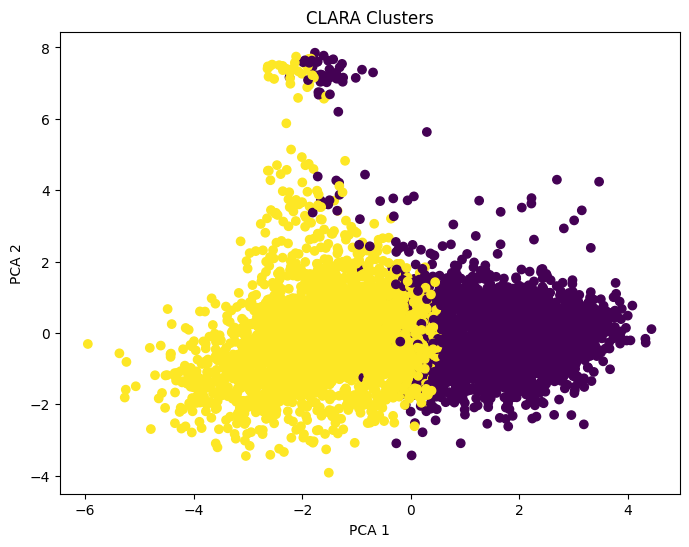

In [70]:
show_clusters(labels, clara.__class__.__name__)

Here CLARA very well splits data into to clusters showing an almsot clear line between them

### Hierarchical (Agglomerative and Divisive methods)

In [99]:
from sklearn.cluster import AgglomerativeClustering

silhouette = []
db_score = []
ch_score = []

clusters = range(2, 10)
for cluster in clusters:
  model = AgglomerativeClustering(n_clusters=cluster)

  labels = model.fit_predict(X_scaled)

  silhouette.append(silhouette_score(X_scaled, labels, sample_size=10000))
  db_score.append(davies_bouldin_score(X_scaled, labels))
  ch_score.append(calinski_harabasz_score(X_scaled, labels))

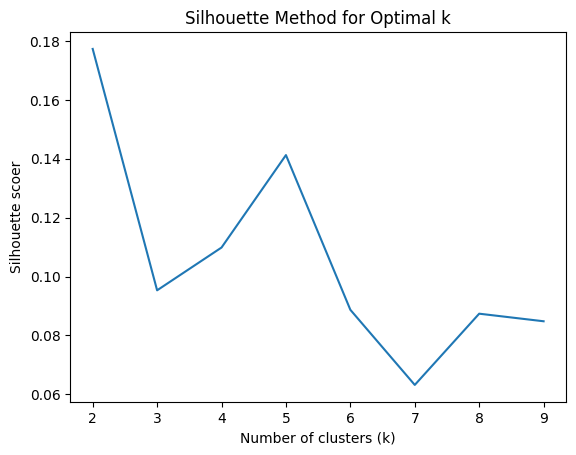

In [98]:
import matplotlib.pyplot as plt

plt.plot(clusters, silhouette)
plt.title('Silhouette Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette scoer')
plt.xticks(clusters)

plt.show()

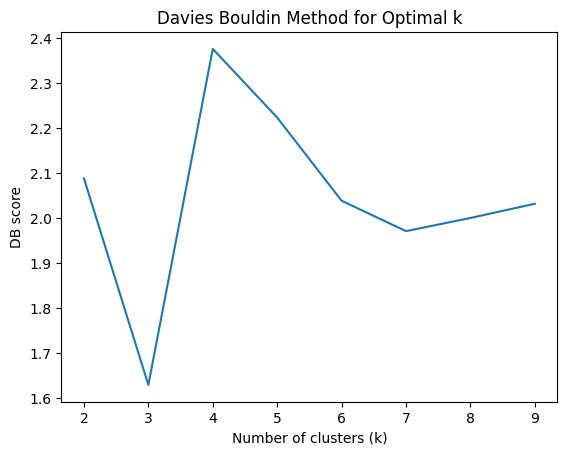

In [100]:
import matplotlib.pyplot as plt

plt.plot(clusters, db_score)
plt.title('Davies Bouldin Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('DB score')
plt.xticks(clusters)

plt.show()

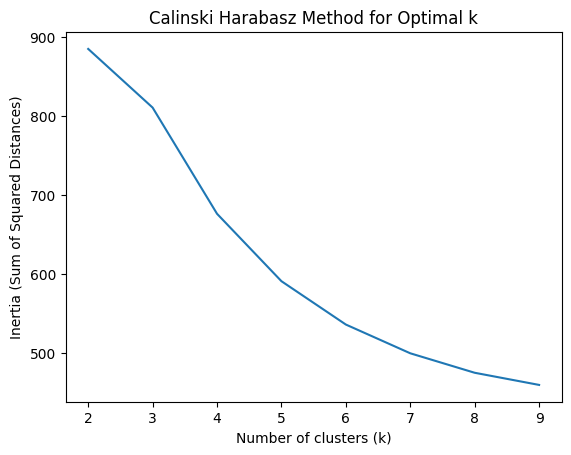

In [101]:
import matplotlib.pyplot as plt

plt.plot(clusters, ch_score)
plt.title('Calinski Harabasz Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(clusters)

plt.show()

In [104]:
aggl = AgglomerativeClustering(n_clusters=3)
labels = aggl.fit_predict(X_scaled)

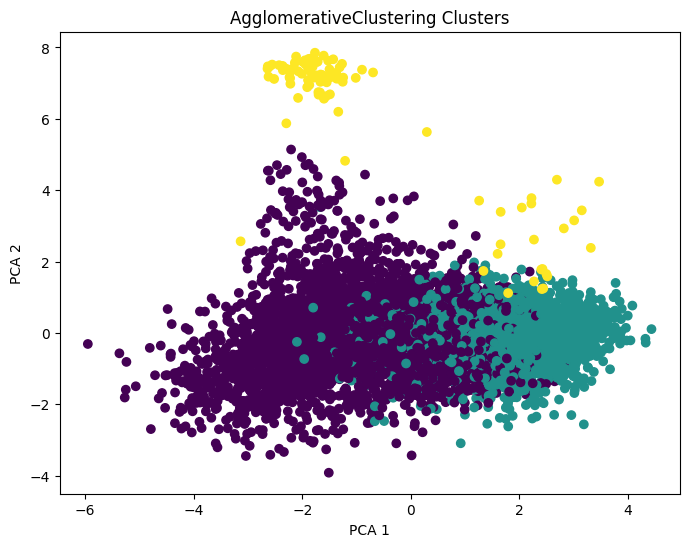

In [105]:
show_clusters(labels, aggl.__class__.__name__)

This shows not a really good result. Bottom clusters overlap and yelllow is dispersed

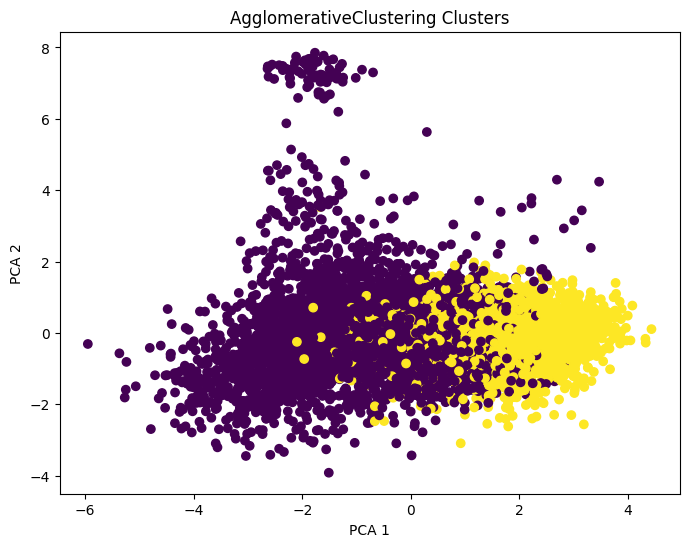

In [75]:
aggl = AgglomerativeClustering(n_clusters=2)
labels = aggl.fit_predict(X_scaled)
show_clusters(labels, aggl.__class__.__name__)

Results is actually weak. The overlap between two clusters remains to be the same.

### Density-based method (DBSCAN)

In [76]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.2, min_samples=10)
labels = model.fit_predict(X_scaled)

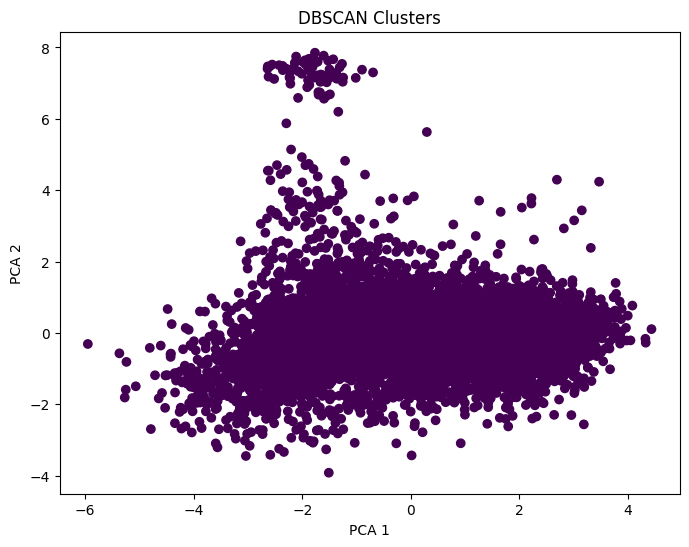

In [78]:
show_clusters(labels, model.__class__.__name__)

According to Density-based method there is only one cluster. It happens because all data in here is dense and dont have any kind of separation.

### Model based (Self-Organizing Map (SOM))

In [79]:
!pip install minisom

In [80]:
from minisom import MiniSom
import numpy as np

som = MiniSom(
    x=8,
    y=8,
    input_len=X_scaled.shape[1],
    sigma=1.5,
    learning_rate=0.3
)

X_array = X_scaled.to_numpy()
som.random_weights_init(X_array)
som.train_random(X_array, 1000)

mapped = np.array([som.winner(x) for x in X_array])

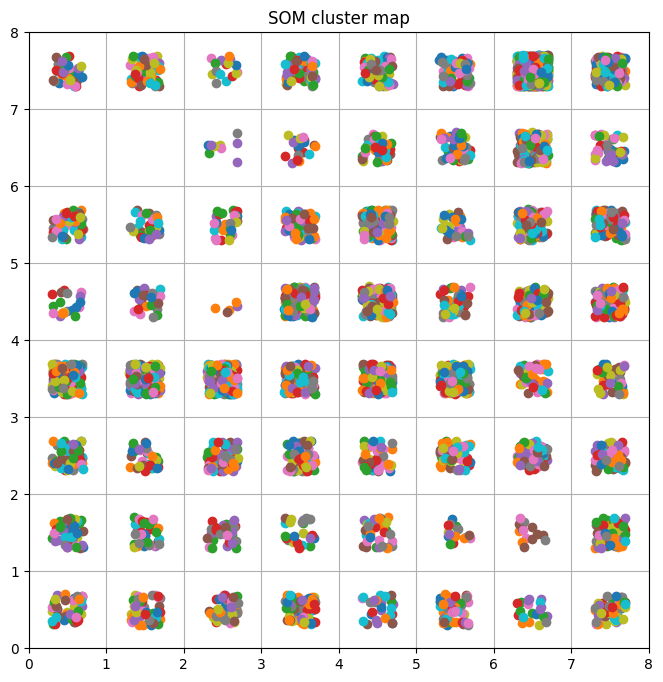

In [81]:
plt.figure(figsize=(8, 8))

for m in mapped:
    plt.plot(
        m[0] + 0.5 + np.random.uniform(-0.2, 0.2),
        m[1] + 0.5 + np.random.uniform(-0.2, 0.2),
        'o'
    )

plt.xlim([0, som._weights.shape[0]])
plt.ylim([0, som._weights.shape[1]])
plt.title("SOM cluster map")
plt.grid()
plt.show()

Data is spread across almost all neurons, so does not form a few tight clusters — it’s continuous / smoothly distributed.

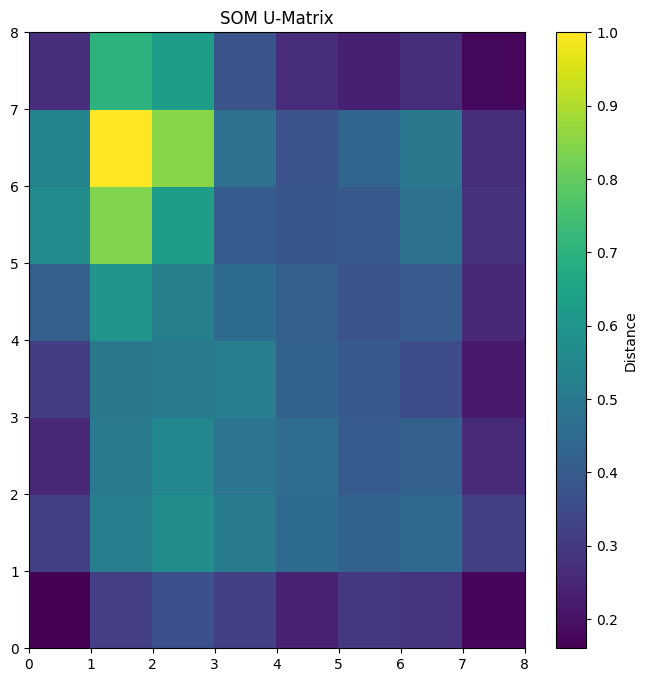

In [82]:
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T)
plt.colorbar(label="Distance")
plt.title("SOM U-Matrix")
plt.show()

The yellow here means that it is a string separation in data at those coordinates.
Based on very dark cells those might be clusters. So here might be 3-4 clusters